# Exercise 4: NumPy Array Operations

In [1]:
import numpy as np

matrix = np.ones((5, 5))
matrix[1:-1, 1:-1] = 0

matrix

array([[1., 1., 1., 1., 1.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [1., 1., 1., 1., 1.]])

# Normalization

In [2]:
np.random.seed(42)
random_data = np.random.randn(100, 3)

normalized = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)

normalized[:5]

array([[ 0.49343924,  0.04616031,  0.51734005],
       [ 1.74402998, -0.05226901, -0.27901188],
       [ 1.81249029,  0.97585261, -0.49153853],
       [ 0.54930358, -0.28760687, -0.48815686],
       [ 0.18301785, -1.77587837, -1.62529439]])

# Linear regression

In [3]:
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("True theta:", true_theta)
print("Estimated theta:", theta_hat)

True theta: [ 2.5 -1.2  3.7]
Estimated theta: [ 2.51723721 -1.19783796  3.72399266]


# EXERCISE 5:Pandas Data Analysis

In [4]:
import pandas as pd
import numpy as np

In [6]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Analysis

In [7]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             200 non-null    float64
 4   assignments_completed  200 non-null    int32  
 5   hours_studied          200 non-null    float64
dtypes: float64(2), int32(1), int64(2), str(1)
memory usage: 8.7 KB
None
student_id               0
major                    0
year                     0
exam_score               0
assignments_completed    0
hours_studied            0
dtype: int64


In [8]:
# Fill exam_score using mean per major
df['exam_score'] = df.groupby('major')['exam_score'].transform(
    lambda x: x.fillna(x.mean())
)

# Fill hours_studied using median per year
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(
    lambda x: x.fillna(x.median())
)

# Average exam score by major

In [9]:
print(df.groupby('major')['exam_score'].mean())

major
Biology    75.512235
CS         76.325665
Math       75.085935
Physics    75.490838
Name: exam_score, dtype: float64


# Correlation

In [10]:
print(df[['hours_studied', 'exam_score']].corr())

               hours_studied  exam_score
hours_studied       1.000000   -0.036509
exam_score         -0.036509    1.000000


# performance categories

In [12]:
df['performance'] = pd.cut(
    df['exam_score'],
    bins=[0, 70, 80, 90, 100],
    labels=['Needs Improvement', 'Average', 'Good', 'Excellent']
)

df.head()

,student_id,major,year,exam_score,assignments_completed,hours_studied,performance
0,1000,Physics,3,68.199753,10,10.922505,Needs Improvement
1,1001,Biology,4,77.322537,9,12.204873,Average
2,1002,CS,3,77.930725,9,7.829556,Average
3,1003,Physics,1,67.856486,2,14.042336,Needs Improvement
4,1004,Physics,4,93.657745,6,15.287370,Excellent


# Group by major + year

In [13]:
df.groupby(['major', 'year']).agg({
    'student_id': 'count',
    'exam_score': 'mean',
    'hours_studied': 'mean'
})

student_id  exam_score  hours_studied
major   year                                       
Biology 1             13   76.570059      12.677806
        2             12   74.454155      13.426372
        3             14   80.595336      15.095221
        4             15   70.697689      14.253944
CS      1             12   76.716704      13.039480
        2              7   76.155936      13.595825
        3              9   72.347626      15.039892
        4             18   78.119997      16.275541
Math    1             11   74.554794      19.001215
        2              9   82.669539      12.654613
        3             10   72.017537      15.175871
        4             16   73.103066      17.317643
Physics 1             13   77.164939      13.489911
        2             12   73.277734      14.616778
        3             17   73.220085      14.017038
        4             12   79.107233      15.550491

# Top 5 students

In [14]:
top5 = df.sort_values('exam_score', ascending=False).head(5)
top5

,student_id,major,year,exam_score,assignments_completed,hours_studied,performance
57,1057,CS,2,100.000000,8,11.870035,Excellent
27,1027,Math,2,100.000000,4,2.716265,Excellent
68,1068,Biology,3,98.146586,1,11.379991,Excellent
82,1082,CS,2,96.439441,0,7.378547,Excellent
132,1132,CS,4,96.330334,10,17.546891,Excellent


# Pivot table

In [15]:
pivot = df.pivot_table(
    values='exam_score',
    index='major',
    columns='year'
)

pivot

year,1,2,3,4
major,,,,
Biology,76.570059,74.454155,80.595336,70.697689
CS,76.716704,76.155936,72.347626,78.119997
Math,74.554794,82.669539,72.017537,73.103066
Physics,77.164939,73.277734,73.220085,79.107233


# EXERCISE 6 DATA VISUALIZATION

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution Plot

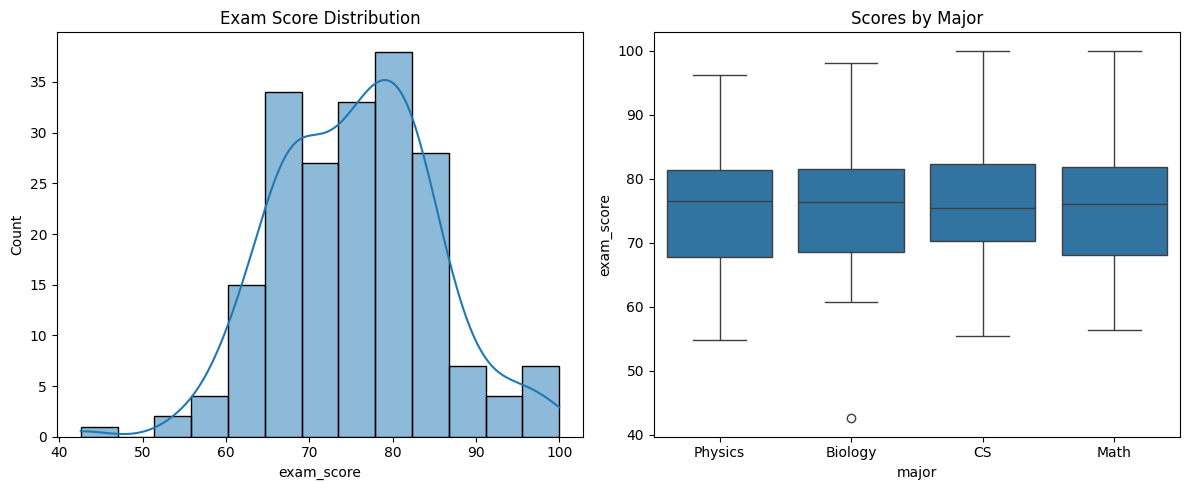

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram + KDE
sns.histplot(df['exam_score'], kde=True, ax=axes[0])
axes[0].set_title("Exam Score Distribution")

# Boxplot by major
sns.boxplot(x='major', y='exam_score', data=df, ax=axes[1])
axes[1].set_title("Scores by Major")

plt.tight_layout()
plt.show()

# Relationship Plot

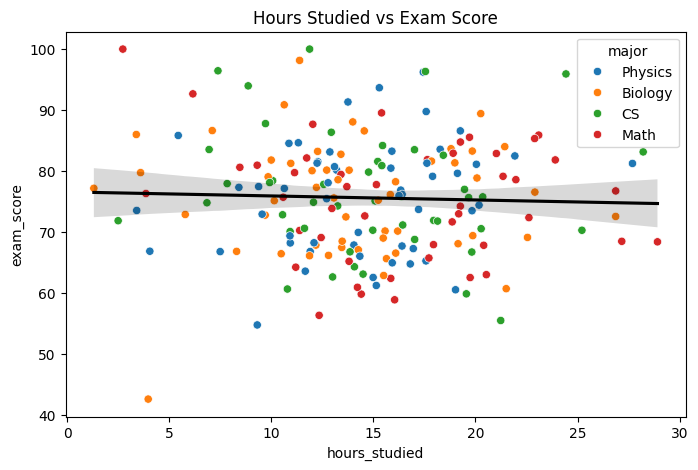

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='hours_studied',
    y='exam_score',
    hue='major',
    data=df
)

sns.regplot(
    x='hours_studied',
    y='exam_score',
    data=df,
    scatter=False,
    color='black'
)

plt.title("Hours Studied vs Exam Score")
plt.show()

# Dashboard

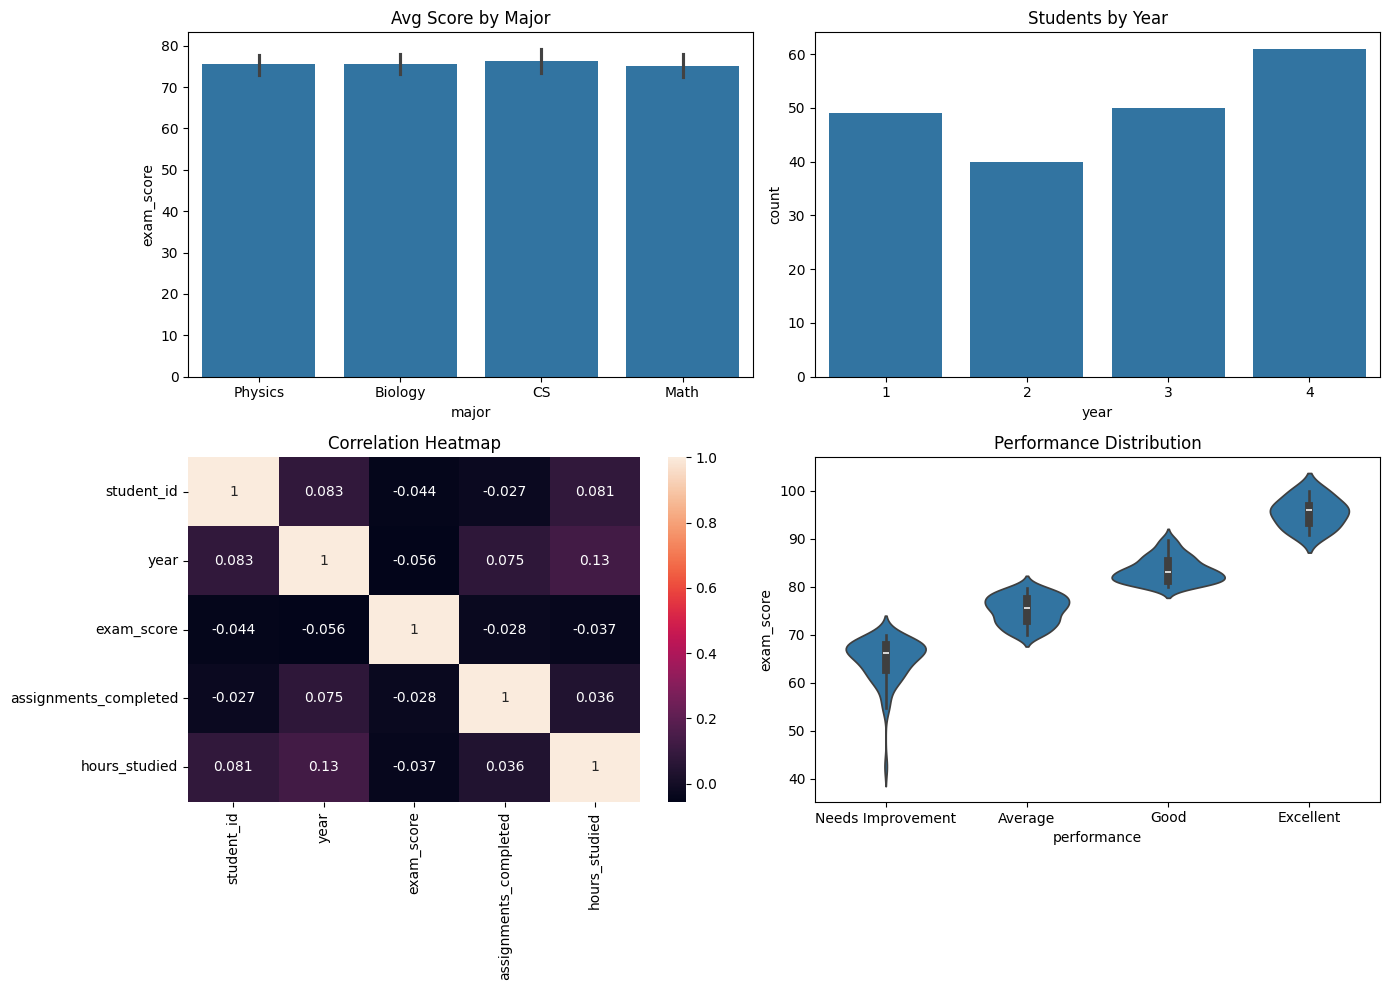

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Avg score by major
sns.barplot(x='major', y='exam_score', data=df, ax=axes[0,0])
axes[0,0].set_title("Avg Score by Major")

# 2. Count by year
sns.countplot(x='year', data=df, ax=axes[0,1])
axes[0,1].set_title("Students by Year")

# 3. Correlation heatmap
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, ax=axes[1,0])
axes[1,0].set_title("Correlation Heatmap")

# 4. Violin plot
sns.violinplot(x='performance', y='exam_score', data=df, ax=axes[1,1])
axes[1,1].set_title("Performance Distribution")

plt.tight_layout()
plt.show()

# Exercise 7

# Dataset

In [21]:
import numpy as np
import pandas as pd

np.random.seed(42)
n_customers = 500

ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# CVL Caluculation

In [22]:
max_freq = customers['purchase_frequency'].max()

churn_risk = 1 - (customers['purchase_frequency'] / max_freq)

customers['CLV'] = customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + churn_risk)

customers.head()

,age,income,purchase_frequency,avg_purchase_value,CLV
0,56,92443.123940,7,94.527456,937.397271
1,69,70649.305211,2,100.932279,370.085023
2,46,19612.600681,3,79.699876,418.424348
3,32,40315.318543,2,130.137787,477.171887
4,60,75338.222984,8,102.904845,1097.651683


# Age group

In [23]:
bins = [18, 25, 35, 50, 70]
labels = ['18-25', '26-35', '36-50', '51-70']

customers['age_group'] = pd.cut(customers['age'], bins=bins, labels=labels)

# grouo analysis

In [24]:
customers.groupby('age_group').agg({
    'income': 'mean',
    'CLV': ['mean', 'sum'],
    'age': 'count'
})

income         CLV                  age
                   mean        mean            sum count
age_group                                               
18-25      51805.879852  704.492597   48609.989225    69
26-35      48747.148046  747.738562   54584.915035    73
36-50      48516.895668  732.796612  117247.457917   160
51-70      50713.163384  762.693498  141860.990683   186

# top 10% customers

In [25]:
top_10 = customers.nlargest(int(0.1 * len(customers)), 'CLV')
top_10

,age,income,purchase_frequency,avg_purchase_value,CLV,age_group
426,42,68713.567863,8,154.285448,1645.711441,36-50
213,41,45580.608009,7,164.920221,1635.458860,36-50
410,44,49344.934596,6,177.097211,1593.874900,36-50
194,44,57331.964922,6,176.640590,1589.765308,36-50
244,28,29255.076913,7,159.784979,1584.534373,26-35
423,43,34443.666248,6,173.245130,1559.206172,36-50
386,63,24200.782005,9,136.030443,1530.342482,51-70
187,47,48889.046022,8,143.183371,1527.289296,36-50
361,38,27490.219054,7,153.105028,1518.291532,36-50
180,62,44611.863311,7,151.961479,1506.951331,51-70


# Visualisation

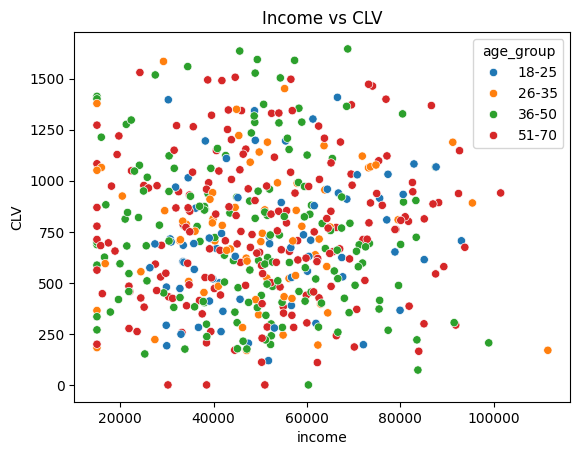

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x='income', y='CLV', hue='age_group', data=customers)
plt.title("Income vs CLV")
plt.show()

# Average cvl by group age

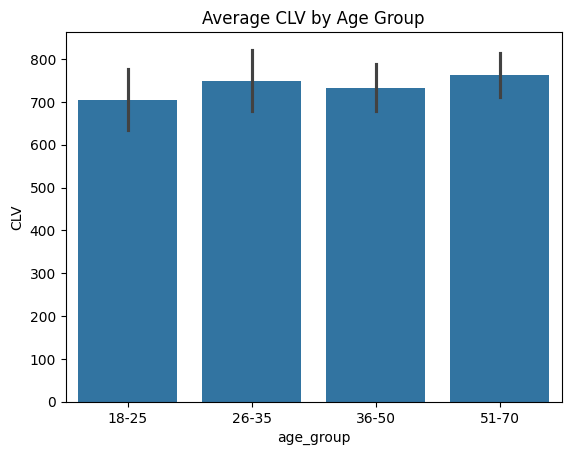

In [27]:
sns.barplot(x='age_group', y='CLV', data=customers)
plt.title("Average CLV by Age Group")
plt.show()

# Correlation heatmap

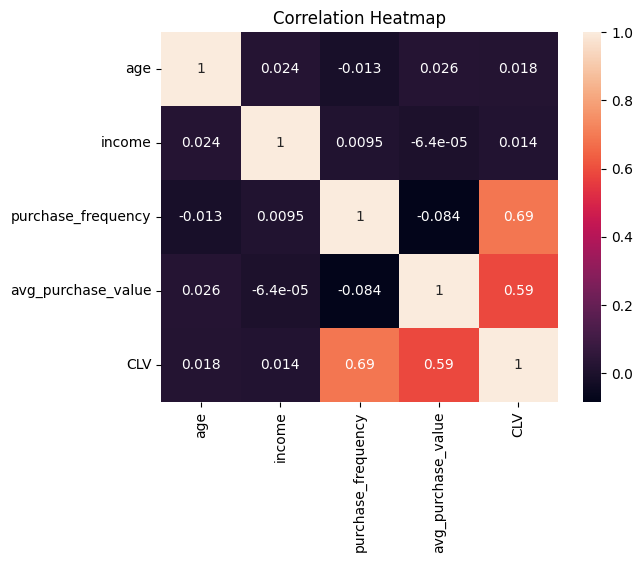

In [28]:
sns.heatmap(customers[['age','income','purchase_frequency','avg_purchase_value','CLV']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Conclusion: I grouped customers by age and studied how income and purchase behavior affect CLV. The visualizations helps understand differences between customer groups and their value to the business. From this I recommad the company to focus marketing strategies on high-frequency customers to maximize revenue and retention.